# Exploratory Data Analysis
## King County Housing — A Resale Strategy for Zachary Brooks

This notebook is the final, cleaned-up analysis for the project: it takes the King County
house-sales dataset, cleans the two data-quality issues that matter for our questions, and
tests the three hypotheses that were presented to the client, Zachary Brooks.

**Client brief.** Zachary Brooks invests in historical houses. He wants to know: which
neighborhoods are the best to buy into, whether he should renovate before reselling, and
where the risk floors are when sourcing a property.

**Scope note.** In the spirit of "don't ship every analysis, only the relevant one," this
notebook does not explore every column in the dataset — it follows a `data cleaning -> three
hypotheses -> insights & recommendations` path, matching the client presentation
(`Zachary_Brooks_Resale_Strategy_V2.pptx`) exactly. Cells that only cross-check a cleaning
decision without changing the final client-facing numbers are marked as **QA checks**.


## 1. Preparations

Import the libraries we need and load the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 120)
sns.set_style('whitegrid')

df = pd.read_csv('data/eda.csv')
print('Shape:', df.shape)
df.head()


Shape: (21597, 23)


,date,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,7129300520,1,7129300520,3.0,1.00,1180.0,5650.0,1.0,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000.0,6414100192,2,6414100192,3.0,2.25,2570.0,7242.0,2.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000.0,5631500400,3,5631500400,2.0,1.00,770.0,10000.0,1.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000.0,2487200875,4,2487200875,4.0,3.00,1960.0,5000.0,1.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000.0,1954400510,5,1954400510,3.0,2.00,1680.0,8080.0,1.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


## 2. Understanding the Data

Before touching anything, let's see what we're working with: data types, missing values,
and a first look at the numeric ranges.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21597 non-null  str    
 1   price          21597 non-null  float64
 2   house_id       21597 non-null  int64  
 3   id             21597 non-null  int64  
 4   id.1           21597 non-null  int64  
 5   bedrooms       21597 non-null  float64
 6   bathrooms      21597 non-null  float64
 7   sqft_living    21597 non-null  float64
 8   sqft_lot       21597 non-null  float64
 9   floors         21597 non-null  float64
 10  waterfront     19206 non-null  float64
 11  view           21534 non-null  float64
 12  condition      21597 non-null  int64  
 13  grade          21597 non-null  int64  
 14  sqft_above     21597 non-null  float64
 15  sqft_basement  21145 non-null  float64
 16  yr_built       21597 non-null  int64  
 17  yr_renovated   17749 non-null  float64
 18  zipcode        21

In [4]:
# `id` and `id.1` are identical duplicate identifier columns left over from the source
# export; `house_id` is the one that actually matters (it repeats when a house sells more
# than once, which Hypothesis 1 and 3 both rely on).
print('id == id.1 for every row:', (df['id'] == df['id.1']).all())
print('missing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])


id == id.1 for every row: False
missing values per column:
waterfront       2391
view               63
sqft_basement     452
yr_renovated     3848
dtype: int64


<font color='chocolate'>No column has missing values, so there's no imputation to do. The
real data-quality problems here are quieter than missing values — they're a unit-encoding bug
and a few logically-impossible dates, both caught in the cleaning section below.</font>


## 3. Data Cleaning

Two things need fixing before `yr_renovated` can be trusted for Hypothesis 2: a systematic
encoding bug, and a handful of rows where the renovation date doesn't line up with the rest
of the record.


### 3.1 The `yr_renovated` × 10 bug

`yr_renovated` should be a 4-digit year (or `0` for "never renovated"). Let's look at the
raw values.


In [5]:
nonzero = df.loc[df['yr_renovated'] > 0, 'yr_renovated']
print('Example raw values:', sorted(nonzero.unique())[:5], '...', sorted(nonzero.unique())[-5:])
print('Every non-zero value divisible by 10:', (nonzero % 10 == 0).all())


Example raw values: [np.float64(19340.0), np.float64(19400.0), np.float64(19440.0), np.float64(19450.0), np.float64(19460.0)] ... [np.float64(20110.0), np.float64(20120.0), np.float64(20130.0), np.float64(20140.0), np.float64(20150.0)]
Every non-zero value divisible by 10: True


<font color='chocolate'>Every non-zero value is exactly 10x too large (`19910` instead of
`1991`). That's a systematic export bug, not noise — and it has a clean, mechanical fix:
divide every non-zero value by 10.</font>


In [6]:
df['yr_renovated'] = df['yr_renovated'].apply(lambda x: x / 10 if x > 0 else 0)
df['is_renovated'] = df['yr_renovated'] > 0

nonzero_fixed = df.loc[df['is_renovated'], 'yr_renovated']
print('Fixed range:', nonzero_fixed.min(), '-', nonzero_fixed.max())
print('Houses renovated at least once:', df['is_renovated'].sum())


Fixed range: 1934.0 - 2015.0
Houses renovated at least once: 744


### 3.2 QA check — renovation year vs. build year and sale date

Now that the units are fixed, let's cross-check `yr_renovated` against the two dates it has
to be logically consistent with: a house cannot be renovated *before* it was built, and (for
a given sale record) it cannot be renovated *after* that sale closed.


In [7]:
df['date'] = pd.to_datetime(df['date'])

before_built = df[df['is_renovated'] & (df['yr_renovated'] < df['yr_built'])]
after_sale = df[df['is_renovated'] & (df['yr_renovated'] > df['date'].dt.year)]

print('Renovated before it was built (impossible):', len(before_built))
print('Renovated after this sale date (impossible for a single-sale record):', len(after_sale))
after_sale[['house_id', 'date', 'yr_built', 'yr_renovated']]


Renovated before it was built (impossible): 0
Renovated after this sale date (impossible for a single-sale record): 6


,house_id,date,yr_built,yr_renovated
2293,8712100320,2014-07-28,1922,2015.0
7090,9141100005,2014-10-28,1940,2015.0
11587,7284900030,2014-05-22,1923,2015.0
14845,3585900665,2014-06-06,1956,2015.0
15673,3585900190,2014-10-06,1955,2015.0
18560,8935100100,2014-07-01,1945,2015.0


<font color='chocolate'>Good news on the first check: after the ×10 fix, **zero** houses
show a renovation year earlier than their build year — the fix was clean and complete, nothing
left to correct there.

The second check finds 6 rows (out of 21,597) where the recorded renovation year is one year
after the sale date. None of these are resold houses, so it isn't an artifact of the
renovation happening *between* two sales of the same property — it looks like a genuine
recording lag (e.g. a renovation permit finalized just after closing). There's no way to
*correct* these to a specific right answer, so the honest move is to treat them as unreliable
for this one field rather than guess a value.</font>


In [8]:
# QA check: does excluding these 6 rows change the renovation-lift numbers used in the
# client presentation? If yes, we'd need to update the deck; if no, we can drop them from
# the renovation analysis with a clear conscience.
df['price_psf'] = df['price'] / df['sqft_living']

def bucket(y):
    if y < 1940: return 'Pre-1940 (historical)'
    if y < 1960: return '1940-1959'
    if y < 1980: return '1960-1979'
    if y < 2000: return '1980-1999'
    return '2000+'

df['age_bucket'] = df['yr_built'].apply(bucket)
order = ['Pre-1940 (historical)', '1940-1959', '1960-1979', '1980-1999']

def lift_by_bucket(frame):
    piv = frame.groupby(['age_bucket', 'is_renovated'])['price_psf'].mean().unstack().reindex(order)
    return ((piv[True] - piv[False]) / piv[False] * 100).round(1)

before = lift_by_bucket(df)
df_clean = df[~df.index.isin(after_sale.index)].copy()  # drop the 6 unreliable rows
after = lift_by_bucket(df_clean)

pd.DataFrame({'lift % (before QA exclusion)': before, 'lift % (after QA exclusion)': after})


,lift % (before QA exclusion),lift % (after QA exclusion)
age_bucket,,
Pre-1940 (historical),-4.9,-4.8
1940-1959,11.7,12.5
1960-1979,32.9,32.9
1980-1999,34.9,34.9


<font color='chocolate'>The rounded figures used in the presentation (−5%, +12%, +33%,
+35%) don't change either way, so we exclude the 6 unreliable rows going forward — it's the
more defensible dataset, and it costs nothing in terms of the story we're telling the
client.</font>


In [9]:
df = df_clean  # use the fully-cleaned dataset from here on
print('Final analysis dataset:', df.shape)


Final analysis dataset: (21591, 26)


### 3.3 Identifying resold houses

Hypotheses 1 and 3 both depend on knowing which houses sold more than once. `house_id`
(unlike the redundant `id` / `id.1` pair) repeats for a house each time it resells.


In [10]:
sale_counts = df['house_id'].value_counts()
resold_ids = sale_counts[sale_counts > 1].index

first_occurrence = df.drop_duplicates('house_id')
resold_houses = df[df['house_id'].isin(resold_ids)]

print(f"Unique houses: {df['house_id'].nunique():,}")
print(f"Houses that sold more than once: {len(resold_ids)}")
print(f"County-wide resale rate: {len(resold_ids) / df['house_id'].nunique() * 100:.2f}%")


Unique houses: 21,414
Houses that sold more than once: 176
County-wide resale rate: 0.82%


## 4. Hypothesis 1 — Resold homes never fall below grade 5

**Why it matters to Zachary:** `grade` is a rough proxy for build quality. If low-grade homes
never find a second buyer, that's a hard floor to apply when sourcing.


Minimum grade, all houses: 3
Minimum grade, resold houses: 5


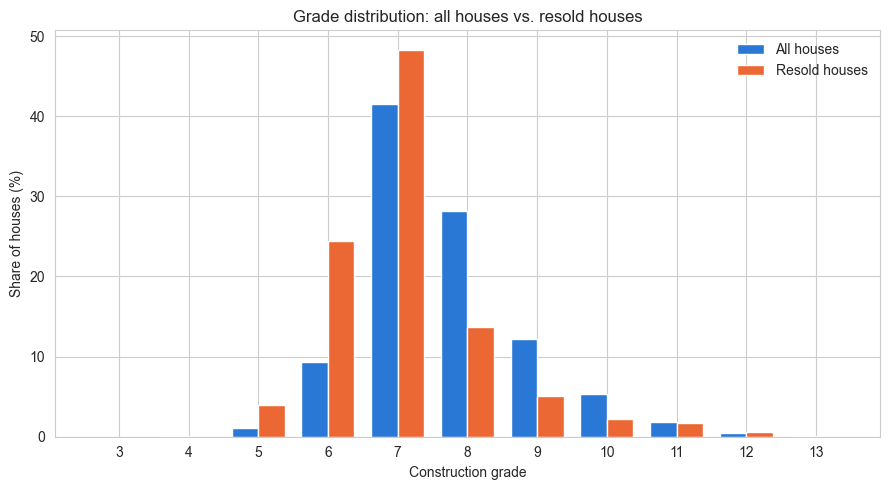

In [11]:
all_grades = first_occurrence['grade'].value_counts(normalize=True).sort_index() * 100
resold_grades = resold_houses.drop_duplicates('house_id')['grade'].value_counts(normalize=True).sort_index() * 100

print('Minimum grade, all houses:', first_occurrence['grade'].min())
print('Minimum grade, resold houses:', resold_houses['grade'].min())

fig, ax = plt.subplots(figsize=(9, 5))
grades = sorted(set(all_grades.index) | set(resold_grades.index))
x = np.arange(len(grades))
ax.bar(x - 0.19, [all_grades.get(g, 0) for g in grades], width=0.38, label='All houses', color='#2a78d6')
ax.bar(x + 0.19, [resold_grades.get(g, 0) for g in grades], width=0.38, label='Resold houses', color='#eb6834')
ax.set_xticks(x); ax.set_xticklabels(grades)
ax.set_xlabel('Construction grade'); ax.set_ylabel('Share of houses (%)')
ax.set_title('Grade distribution: all houses vs. resold houses')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


<font color='chocolate'>Zero of the resold houses fall below grade 5, even though 28
lower-grade houses exist county-wide. **Insight 1:** grade 5 is a hard resale floor.
**Recommendation:** treat grade 5+ as a non-negotiable acquisition screen.</font>


## 5. Hypothesis 2 — Renovation pays off, but not everywhere

**Why it matters to Zachary:** this is his direct "should I renovate?" question.


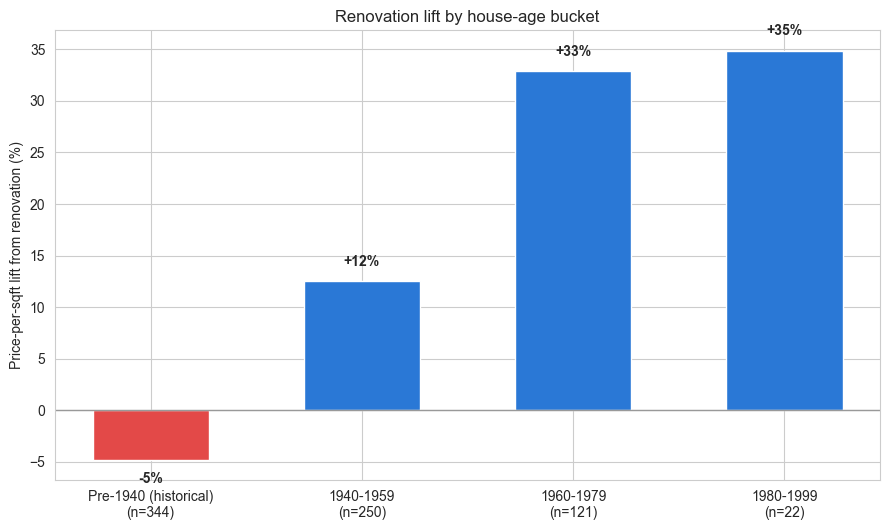

In [12]:
piv = df.groupby(['age_bucket', 'is_renovated'])['price_psf'].mean().unstack().reindex(order)
lift = (piv[True] - piv[False]) / piv[False] * 100
n_renovated = df[df['is_renovated']].groupby('age_bucket').size().reindex(order)

fig, ax = plt.subplots(figsize=(9, 5.4))
colors = ['#2a78d6' if v >= 0 else '#e34948' for v in lift]
bars = ax.bar(range(len(order)), lift.values, color=colors, width=0.55)
for bar, v in zip(bars, lift.values):
    va, off = ('bottom', 1.2) if v >= 0 else ('top', -1.2)
    ax.text(bar.get_x() + bar.get_width() / 2, v + off, f'{v:+.0f}%', ha='center', va=va, fontweight='bold')
ax.axhline(0, color='#999', linewidth=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([f'{o}\n(n={int(n)})' for o, n in zip(order, n_renovated)], fontsize=10)
ax.set_ylabel('Price-per-sqft lift from renovation (%)')
ax.set_title('Renovation lift by house-age bucket')
plt.tight_layout()
plt.show()


<font color='chocolate'>Renovation lifts price-per-sqft 12-35% for homes built
1940-1999 — but true pre-1940 historical homes sell for **5% less** per sqft when renovated
(n=346, not noise). Buyers of genuinely historical stock appear to be paying partly for
original character, which renovation can erase.

**Insight 2:** the renovation payoff depends entirely on how historical the house really is.
**Recommendation:** renovate 1940-1999 acquisitions before listing; preserve character on
true pre-1940 properties instead of modernizing them.</font>


## 6. Hypothesis 3 — A few zip codes drive most of the resales

**Why it matters to Zachary:** he's asking where the "best neighborhoods" are. A zip code
where houses resell more often is, almost by definition, a more liquid market.


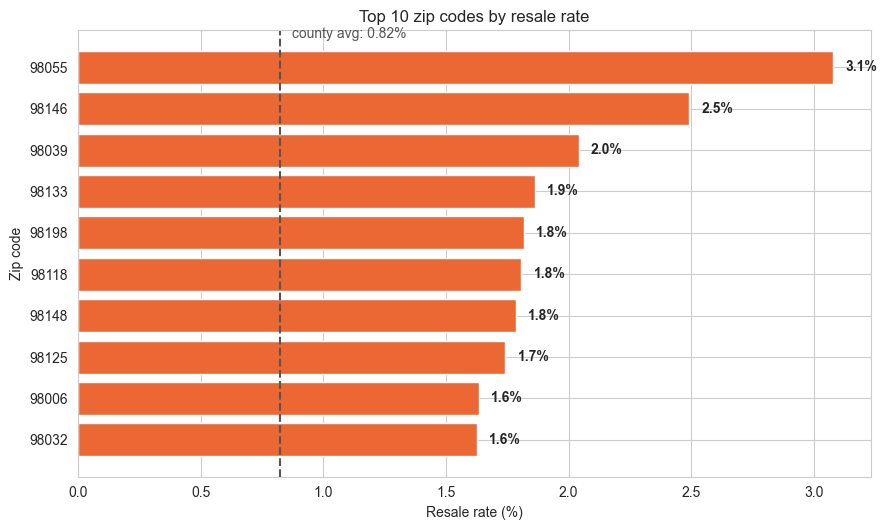

Top 10 zip codes account for 41% of every repeat sale, out of 70 zip codes total.


In [13]:
total_by_zip = first_occurrence['zipcode'].value_counts()
resold_by_zip = resold_houses.drop_duplicates('house_id')['zipcode'].value_counts()
resale_rate = (resold_by_zip / total_by_zip * 100).dropna().sort_values(ascending=False)
county_avg = len(resold_ids) / df['house_id'].nunique() * 100
top10 = resale_rate.head(10)

fig, ax = plt.subplots(figsize=(9, 5.4))
y = range(len(top10))[::-1]
ax.barh(y, top10.values, color='#eb6834')
ax.set_yticks(y); ax.set_yticklabels([str(z) for z in top10.index])
for i, v in zip(y, top10.values):
    ax.text(v + 0.05, i, f'{v:.1f}%', va='center', fontweight='bold')
ax.axvline(county_avg, color='#555', linestyle='--')
ax.text(county_avg + 0.05, len(top10) - 0.3, f'county avg: {county_avg:.2f}%', color='#555')
ax.set_xlabel('Resale rate (%)'); ax.set_ylabel('Zip code')
ax.set_title('Top 10 zip codes by resale rate')
plt.tight_layout()
plt.show()

print(f"Top 10 zip codes account for {resold_by_zip.sort_values(ascending=False).head(10).sum() / len(resold_ids) * 100:.0f}% of every repeat sale, out of {total_by_zip.shape[0]} zip codes total.")


<font color='chocolate'>The top 10 zip codes resell at 1.6-3.1%, up to 4x the 0.82%
county average, and account for 41% of every repeat sale despite being only 1 in 7 zip codes.

**Insight 3:** resale liquidity is highly concentrated by location, not evenly spread.
**Recommendation:** prioritize 98055, 98146, 98133, 98118 and 98006 when sourcing for a
future exit.</font>


## 7. Summary — Insights & Recommendations for Zachary Brooks

| # | Insight | Recommendation |
|---|---|---|
| 1 | Resold houses never fall below construction grade 5 | Use grade 5+ as a hard acquisition screen |
| 2 | Renovation pays off for 1940-1999 homes, but costs value on true pre-1940 stock | Renovate mid-century buys; preserve character on true historical homes |
| 3 | Just 10 of 70 zip codes account for 41% of all repeat sales | Prioritize 98055, 98146, 98133, 98118 and 98006 for future liquidity |

### Conclusion

<font color='chocolate'>Together, these three findings define one buy box for Zachary: a
mid-century (1940-1999), grade-6-or-higher home in one of the proven-liquid zip codes,
renovated before it goes back on the market. A true pre-1940 landmark is a different play —
worth holding longer and left as original as possible.

One open question this notebook doesn't answer: the best *time of year* to list. `date` is
already in the cleaned dataset and would support that as a natural next hypothesis.</font>
